# Cyberbully Shield: Evaluation Metrics (Optimized Run)

This notebook loads the optimized trained model and performs validation on the 40k test subset. It plots the ROC-AUC curve, Confusion Matrix, and prints Precision, Recall, and F1-Score.
import torchvision
import torchvision.models


In [3]:
import os
import sys
import torchvision
import torchvision.models
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support, accuracy_score

sys.path.append(os.path.abspath('../src'))
from model import CyberbullyShieldFusion
from data_ingestion import get_dataloaders, load_all_datasets
from tqdm import tqdm


In [4]:
# Setup Device and Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = CyberbullyShieldFusion().to(device)
checkpoint_path = '../checkpoints/best_shield_model.pth'

if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Model weights loaded successfully!")
else:
    print(f"Checkpoint not found at {checkpoint_path}")

model.eval()

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model weights loaded successfully!


CyberbullyShieldFusion(
  (text_model): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (

In [5]:
# Load validation data
print('Loading optimized 40K subset...')
train_df, val_df = load_all_datasets('D:/THE_CYBERBULLY_SHIELD/Datasets')
_, val_loader = get_dataloaders(train_df, val_df, batch_size=4)

Loading optimized 40K subset...
Loaded 11100 rows from cyberbullying-tweets.csv
Loaded text files from D:/THE_CYBERBULLY_SHIELD/Datasets\cyberbullying-dataset
Loaded 5793 rows from multimodal-cyberbullying
Total Unified Samples: 465767 | Train: 419190 | Val: 46577


In [6]:
# Evaluation Loop
all_labels = []
all_probs = []
all_preds = []

def evaluate(val_loader):
    val_pbar = tqdm(val_loader, desc='Evaluating')
    with torch.no_grad():
        for batch in val_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image_tensor = batch['image_tensor'].to(device)
            labels = batch['label'].to(device)
            
            # Get Logits and calculate probabilities with Sigmoid
            logits = model(input_ids, attention_mask, image_tensor)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    return np.array(all_labels), np.array(all_probs), np.array(all_preds)

labels, probs, preds = evaluate(val_loader)

Evaluating: 100%|██████████| 11645/11645 [10:30<00:00, 18.46it/s]


Accuracy:  0.9470
Precision: 0.8192
Recall:    0.7880
F1 Score:  0.8033


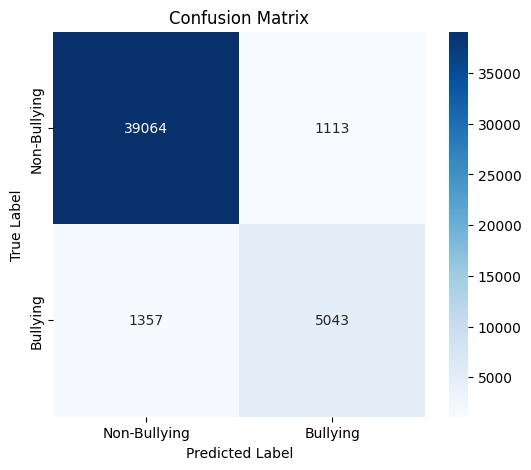

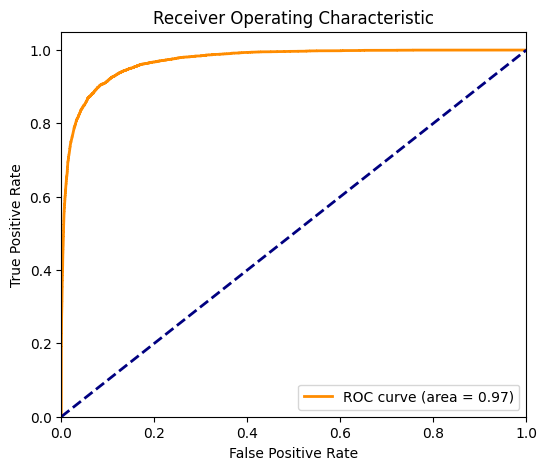

In [7]:
def plot_metrics(labels, probs, preds):
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Bullying', 'Bullying'], yticklabels=['Non-Bullying', 'Bullying'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # --- ROC AUC Curve ---
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

plot_metrics(labels, probs, preds)